<a href="https://colab.research.google.com/github/nainikadevireddy/JohnsHopkinsAI/blob/main/Deep%20Neural%20Networks/4%3A%20Netflix%20Competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<small><font color=gray>Notebook author: <a href="https://www.linkedin.com/in/olegmelnikov/" target="_blank">Oleg Melnikov</a> ©2021 onwards</font></small><hr style="margin:0;background-color:silver">

**<font size=6>🍿Netflix</font>**. [**Instructions**](https://colab.research.google.com/drive/1riOGrE_Fv-yfIbM5V4pgJx4DWcd92cZr#scrollTo=ITaPDPIQEgXV) for running Colabs.

<details>
  <summary><small>Sharing consent: <mark>[ X ]</mark></summary>
  <div>
We consent to sharing our Colab (after the assignment ends) with other students/instructors for educational purposes. We understand that sharing is <b>optional</b> and this decision will not affect our grade in any way. <font color=gray><i>
Instructions: If ok with sharing your Colab for educational purposes, leave "X" in the check box.</i></font></small></div>

In [ ]:
from google.colab import drive; drive.mount('/content/drive')   # OK to enable, if your kaggle.json is stored in Google Drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !pip install --upgrade imgaug==0.2.5 >> log  # avoids warning/conflict with scipy upgrade
# !pip install --upgrade scipy >>log  # upgrades 1.4 to 1.8
# !pip install --upgrade --force-reinstall --no-deps kaggle >> log  # upgrade kaggle package (to avoid a warning)

In [ ]:
!mkdir -p ~/.kaggle                                           # .kaggle folder must contain kaggle.json for kaggle executable to properly authenticate you to Kaggle.com
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json >>log  # First, download kaggle.json from kaggle.com (in Account page) and place it in the root of mounted Google Drive
!cp kaggle.json ~/.kaggle/kaggle.json >> log                   # Alternative location of kaggle.json (without a connection to Google Drive)
!chmod 600 ~/.kaggle/kaggle.json                              # give only the owner full read/write access to kaggle.json
!kaggle config set -n competition -v 10feb25-netflix          # set the competition context for the next few kaggle API calls. !kaggle config view - shows current settings
!kaggle competitions download >> log                          # download competition dataset as a zip file
!unzip -o *.zip >> log                                        # Kaggle dataset is copied as a single file and needs to be unzipped.
!kaggle competitions leaderboard --show                       # print public leaderboard

cp: cannot stat 'kaggle.json': No such file or directory
- competition is now set to: 10feb25-netflix
Using competition: 10feb25-netflix
  teamId  teamName                        submissionDate       score         
--------  ------------------------------  -------------------  ------------  
13357253  2.Shunguan_Ray_Julia            2025-02-23 20:15:38  0.4216000000  
13358315  Team 6                          2025-02-23 16:47:11  0.4145000000  
13373538  🍿 Team1_ArvinJoshSean           2025-02-24 04:26:00  0.4125000000  
13355315  Group3_Casimir_Joshua_Shailesh  2025-02-24 01:25:56  0.4120000000  
13352349  Group5                          2025-02-23 23:58:33  0.4112000000  
13355573  Group_8_Eric_Cristhian_Jack     2025-02-23 04:05:53  0.4107000000  
13385227  4_Charles_Shrinit_Yang          2025-02-24 04:19:27  0.4100000000  
13357312  9 Barshay Marx Simmons          2025-02-24 00:36:38  0.4084000000  
13356616  7_Jung_Oluwatobi_Daniel         2025-02-24 02:00:43  0.4065000000  
13362

In [ ]:
%%time
%%capture
%reset -f
!cp metadata.json METADATA
!pip -q install scikit-surprise
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, seaborn as sns, os, tqdm, re, sys, cv2, skimage, plotly.express as px, surprise
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import TruncatedSVD
from scipy.sparse.linalg import svds
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals

class Timer():
  def __init__(self, lim:'RunTimeLimit'=120): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=1000, precision=2, edgeitems=20, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)

CPU times: user 498 ms, sys: 19 ms, total: 517 ms
Wall time: 2.51 s


The matrix below contains ratings that users (user id or `uid`) have given to the movies (movie ID or `mid`). It is 85% blank, but the original dataset was 99% sparse (with ~1 rating per user) [&#127910;](https://youtu.be/ImpV70uLxyw). Your task is not to fill the whole matrix, but to impute `NaN` values in `XY_Netflix.csv`, which is an equivalent representation of `XY_Netflix_matrix.csv`. This is a collaborative filtering problem, where observations and features have some implicit relation. Recall that typically we expect independent observations in a sample (unless we have a time series or video of image frames, etc.). Here our model needs to learn and leverage the dependencies from observed movie ratings. Clustering techniques might be more intuitive here. [Truncated SVD](https://scikit-learn.org/stable/modules/decomposition.html#lsa) is also popular. Supervised models can be used as well, if we can build features describing our users (which we would treat as observations). Note that we have no other information on users except what they have ranked (which might suggest the cluster they belong to, which might offer unobserved (latent) features). [&#127910;](https://youtu.be/8wLKuscyO9I) Since users relate to other users through the movies they ranked, this can also be presented as a [bipartite graph](https://en.wikipedia.org/wiki/Bipartite_graph).

In [ ]:
dfMtx = pd.read_csv('XY_Netflix_matrix.csv', low_memory=False); dfMtx

,1,2,3,4,5,6,7,8,9,10,...,371,372,373,374,375,376,377,378,379,380
0,NaN,NaN,2.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5.0,NaN,5.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128698,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
f = px.imshow(dfMtx.iloc[:2000,:].T, color_continuous_scale='RdBu_r', aspect='auto');  # movies by users (transposed for visual convenience)
f.update_layout(margin=dict(l=0,r=0,b=0,t=0))

In [ ]:
dfMtx.info()   # note the datatypes and any missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128699 entries, 0 to 128698
Columns: 380 entries, 1 to 380
dtypes: float64(380)
memory usage: 373.1 MB


The dataframe below is another representation of the matrix form above. It lists the `uid`$\times$`mid`locations of the values you need to predict (those with `NaN`) and all other non-zero values in the matrix above.

In [ ]:
df = pd.read_csv('XY_Netflix.csv', low_memory=False); df  # user ID, movie ID, rating. NaN=requires predictions

,uid,mid,rtg
0,1,1,NaN
1,2,2,NaN
...,...,...,...
7402070,49692,126,4.0
7402071,9783,37,1.0


In [ ]:
df.rtg.fillna(0).astype(int).value_counts().to_frame().T   # rating frequencies. 0 represents NaN

rtg,4,3,5,2,1,0
count,2451087,2120585,1628122,842056,340222,20000


In [ ]:
dfMov = pd.read_csv('movies.csv'); dfMov.head(2)   # load movie attributes

,mid,Year,Name,voteAvg,voteCnt,popularity,duration,income,budget,releaseDate,...,origLang,spokenLang,ttl,origTtl,URL,kwds,desc,prodComp,prodCtry,tagline
0,1,2004,The Village,6.2,1071,27.49,108.0,256697520,60000000,7/30/04,...,en,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Village,The Village,NaN,"[{""id"": 1328, ""name"": ""secret""}, {""id"": 5774, ...",When a willful young man tries to venture beyo...,"[{""name"": ""Scott Rudin Productions"", ""id"": 258...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",There is no turning back
1,2,1997,Liar Liar,6.4,1424,26.72,86.0,181000000,45000000,3/21/97,...,en,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Liar Liar,Liar Liar,NaN,"[{""id"": 387, ""name"": ""california""}, {""id"": 102...",Fletcher Reede is a fast-talking attorney and ...,"[{""name"": ""Imagine Entertainment"", ""id"": 23}, ...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",Trust me.


In [ ]:
tmr = Timer()

⏳ started. You have 120 sec. Good luck!


<hr color=green size=40>

<strong><font color=green size=5>⏳Timed Green Playground (TGP): Your ideas, code, documentation, and timer START HERE!</font></strong>

<font color=green>Students: Keep all your definitions, code, documentation in <b>TGP</b>. Modifying any code outside of TGP incurs penalties.

<font color=green><h3><b>Import Necessary Libraries</b><h3>

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

<font color=green><h3><b>Identify Test Set from Dataset


In [ ]:
if 'dfMtx' in vars(): del dfMtx   # release ~400MB RAM
dfK = df[df.rtg!=df.rtg]          # uid-mid-rtg for Kaggle submission (contains NaN ratings)
dfX = df[df.uid.isin(dfK.uid.unique())]  # all ratings on users requiring predictions (as adjacency list)
dfX = dfX.pivot_table(index='uid', columns='mid', values='rtg')  # convert to (adjacency) matrix format

<font color=green><h3><b>Compute User and Movie Statistics for Data Imputation

In [ ]:
# Compute Movie and User Statistics
movie_means = dfX.mean()
user_means = dfX.T.mean()
user_medians = dfX.T.median()
user_stds = dfX.T.std().fillna(0)  # Standard deviation of each user

# Adjust Weights for More Dynamic Blending
w_m = 1 / (1 + user_stds)  # Weight for movie mean
w_u = user_stds / (1 + user_stds)  # Weight for user mean

# Apply Improved Weighted Hybrid Imputation
dfX_blended = dfX.copy()
for user in dfX.index:
    user_median = user_medians[user]
    if user_median in [1, 2, 5]:  # Preserve extreme rating users
        dfX_blended.loc[user] = w_m[user] * movie_means + w_u[user] * user_medians[user]
    else:
        dfX_blended.loc[user] = w_m[user] * movie_means + w_u[user] * user_means[user]

# <font color=green><h3><b>Validation of Model

In [ ]:
### USED FOR VALIDATION

# Tune k values for SVD with 3-Fold Masking Validation
#k_values = [3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50]  # We already found k=8 to be optimal, so keep that
#best_accuracy = 0

#misclassified_counts = {i: 0 for i in range(1, 6)}  # Track mispredicted ratings

#for k in k_values:
#    fold_accuracies = []
#    for fold in range(10):  # 3-Fold Masking Validation
#        np.random.seed(fold * 35)  # Different mask for each fold

#        # Mask a fraction of the known ratings (simulate missing values)
#        mask = dfX.notna()
#        masked_entries = np.argwhere(mask.values)
#        n_mask = int(len(masked_entries) * 0.2)  # Remove 30% per fold
#        masked_indices = masked_entries[np.random.choice(len(masked_entries), n_mask, replace=False)]

#        train_masked = dfX.copy()
#        for i, j in masked_indices:
#            train_masked.iat[i, j] = np.nan  # Remove selected ratings

#        # Apply Weighted Hybrid Imputation
#        train_est = train_masked.fillna(dfX_blended)

#        # Ensure no NaN or Inf values before applying SVD
#        train_est.replace([np.inf, -np.inf], np.nan, inplace=True)
#        train_est.fillna(train_est.mean(), inplace=True)

#        # Apply Truncated SVD
#        np.random.seed(0)
#        for _ in range(50):
#            U, D, Vt = svds(train_est.to_numpy(), k=k)
#            train_est.loc[:, :] = U @ np.diag(D) @ Vt  # Reconstruct matrix
#            mask = ~np.isnan(train_masked)  # Restore known ratings
#            train_est[mask] = train_masked[mask]

#        # Extract evaluation ratings
#        y_true = pd.Series({(i, j): dfX.iloc[i, j] for i, j in masked_indices}, dtype=int)
#        y_pred = pd.Series({(i, j): train_est.iloc[i, j] for i, j in masked_indices}).round().clip(1, 5).astype(int)
#        acc = accuracy_score(y_true, y_pred)
#        fold_accuracies.append(acc)

#        # Track misclassified ratings
#        misclassified = y_true[y_true != y_pred]
#        for rating in misclassified:
#            misclassified_counts[rating] += 1

#    mean_acc = np.mean(fold_accuracies)
#    print(f'Weighted Hybrid Imputation, k={k}, Mean 3-Fold Validation Accuracy: {mean_acc:.4f}')

#    if mean_acc > best_accuracy:
#        best_accuracy = mean_acc
#        best_k = k

#print(f'Best k={best_k} with Mean 3-Fold Accuracy={best_accuracy:.4f}')

# Display misclassified rating distribution
#plt.bar(misclassified_counts.keys(), misclassified_counts.values())
#plt.xlabel('Rating Value')
#plt.ylabel('Number of Misclassifications')
#plt.title('Distribution of Misclassified Ratings in Validation')
#plt.show()

# Display Validation Accuracy
#plt.bar([f'k={best_k}'], [best_accuracy])
#plt.ylim(0, 1)
#plt.ylabel('Accuracy')
#plt.title('Best Mean 3-Fold Validation Accuracy with Weighted Hybrid Imputation')
#plt.show()

<font color=green><h3><b>Training the Final Model

In [ ]:
# Train Final Model on Full Dataset using Weighted Hybrid Imputation
X_filled = dfX.fillna(dfX_blended)

# Ensure no NaN or Inf values before applying SVD
X_filled.replace([np.inf, -np.inf], np.nan, inplace=True)
X_filled.fillna(X_filled.mean(), inplace=True)

np.random.seed(0)
for _ in range(50):  # Apply multiple times for refinement
    U, D, Vt = svds(X_filled.to_numpy(), k=5)
    X_filled.loc[:, :] = U @ np.diag(D) @ Vt
    mask = ~np.isnan(dfX)
    X_filled[mask] = dfX[mask]

<font color=green><h3><b>Output Predictions for Kaggle Submission

In [ ]:
# Prepare Kaggle Submission
dfX_est_L = X_filled.unstack().reset_index().round(0).astype(int).rename(columns={0: 'rtg'})
dfK = dfX_est_L.merge(dfK, on=['mid', 'uid'], suffixes=['', '_']).drop('rtg_', axis=1)
dfK.index = (dfK.uid - 1) * dfK.mid.max() + dfK.mid
dfK['rtg'] = dfK['rtg'].clip(1, 5)

ToCSV(dfK[['rtg']].sort_index(), 'attempt')

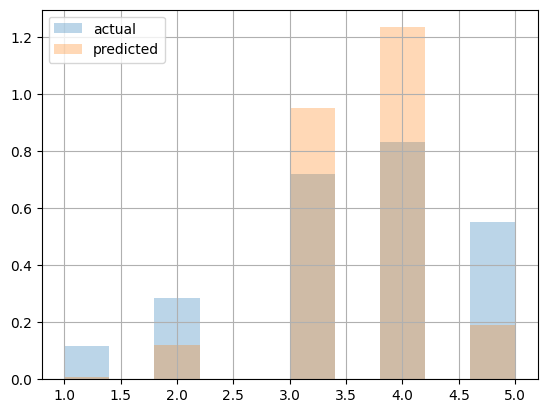

In [ ]:
# evaluate unconditional distributions of observed and predicted ratings. Learn from the differences to focus on wrong predictions
plt.subplot(1, 1, 1)
_ = df.rtg.dropna(axis=0).astype(int).hist(density=True, alpha=0.3);
_ = dfK.rtg.astype(int).hist(density=True, alpha=0.3);
_ = plt.legend(['actual','predicted']);

In [ ]:
!kaggle competitions submit -c 10feb25-netflix -f attempt.csv -m "Message"

100% 192k/192k [00:00<00:00, 507kB/s]
Successfully submitted to 10feb25-🍿Netflix

<font color=green><h3><b>$\gamma$. Idea Documentation</b></h3>
<details>
  <summary>Instructions</summary>
  <div>


1. **Audience**. Your peers who will learn from your Colab and ideas therein.
1. **Importance**. The ML/DL ideas are not entirely random, but are based on prior experience and systematized/organized experiments. We'd like students to share and learn from idea generation to idea experimentation process done in our class using tools learned thus far.
1. **Format**. Keep it concise/precise in consistent font/presentation. Include numbers/IDs to your References, such as [1] or [[Géron22]](https://scholar.google.com/scholar?cluster=498861685923226475), where these are defined in your References section below. This helps link your ideas/experiments to external ideas.
1. **Reproducibility**. Your description should contain reasonable details needed for reproducibility, i.e. describe the state of your modeling pipeline before the change is made, what is changed and how the idea was discovered, and what improvement it resulted in. Thus, peers can try this idea with an expectation of the value it brings. See examples below.
1. **Bonus** points for the exceptional/exemplary/educational documentation (see grading rubric).
****
1. **TODO**: Describe the key idea in your work in the following format (similar to a "micro publication"):
  1. **Title**. Give each idea a descriptive name (i.e. a micro abstract).
    1. Ex(ample). <i>"Thresholding carat feature outliers improves MAE by 3% on public LB"</i>
  1. **Idea Discovery**. What led you to this idea? Was it some [EDA](https://en.wikipedia.org/wiki/Exploratory_data_analysis), familiarity with this dataset or some of the features?
    1. Ex. <i>"We plotted all univariate distributions of variables and discovered that diamond carat had unreasonable (but rare) values below and above [0,10] interval, when plotted carat's histogram in the train and test sets, which contained 10 and 3 such outliers respectively. We decided to use 10 as a reasonable threshold because it is 99th percentile of carat values in the 20K baseline sample. See our histogram plot below [plot here]. "</i>
  1. **Finding's Importance**. Describe why you think the idea was important to proceed with.
    1. Ex. <i>"We use a linear model, the slope of which is sensitive to outliers on the periphery of the feature space domain. The fitted hyperplane slopes in the direction of the extreme training feature values thereby mapping a non-existent relation between carat size and diamond price, which is not expected to repeat in the test set. "</i>
  1. **Experiment Setup**.
  How did you set up experiments to test your idea? What resources were helpful? What metric did you select, why and what values did you observe?
    1. Ex. <i>"To alleviate the impact of the outlying feature values, we need to either remove observations with extreme values, or somehow cap them (to stay within the distribution of the other carat values) or use a model insensitive to outliers (such as robust regression). We learned 3 suitable methods for treating outliers in [ref]: ... [It'd be great to briefly describe each method] We tried each one on a Baseline model, while keeping the competition-required [MAE](https://en.wikipedia.org/wiki/Mean_absolute_error) metric. We tested each method locally on the seeded 50/50 split of the 20K training set sampled in baseline Colab."</i>
  1. **Results**. What was the result or metric improvement from implementing the experiment locally and/or on public LB?
    1. Ex. <i>"Baseline MAE was 539.1257546465 in public LB and 530 in local default experiment with 50/50 train-test split. When applied on the same-seed split, Methods 1,2,and 3 showed 1%, 2%, and 5% improvement on the test set. When uploaded to public LB, Method 3 showed a 3% improvement. So, we decided to keep method 3."</i>

</div> </details>
</font>


<font color=green><h4><b>Task 1. Preprocessing Ideas</b></h4>
<details>
  <summary>Instructions</summary>
  <div>Explain a <b>key idea</b> that helped in <b>preprocessing pipeline</b>. This may be about some feature engineering, tricky subsampling, clustering, dimension reduction, etc. Use the format in TODO specified above. Remember to provide citation references for the peers to read more into your work.
</div> </details>
</font>

1. **Title**: Data Imputation
1. **Idea Discovery**: The initial baseline approach used simple movie mean imputation for missing values. However, this resulted in rating distributions that skewed towards the center (ratings of 3-4) rather than preserving the natural distribution of user preferences, as seen in the figure below. In order to account for user biases and the range of ratings for a movie, other imputation methods were explored.

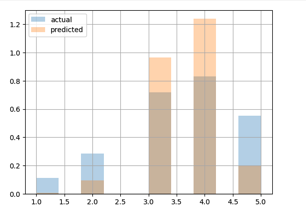
1. **Finding's Importance**: A well-designed imputation strategy prevents information loss and ensures the factorization method operates on a more representative dataset. An imputation method that preserves extreme ratings while still capturing trends in user behavior was needed to prevent the predictions from skewing to ratings 3 and 4. KNN-based imputation was tested to leverage users with similar ratings to infer missing values. A weighted hybrid imputation approach was also tested, which attempted to balance the movie mean with user-specific trends. Other approaches included imputing user mean/median, movie mean/median, and different combinations of weightages of these data statistics.
1. **Experiment Setup**: A 5-fold masking validation strategy was implemented. In each fold, 20% of the known ratings were randomly masked and treated as missing values Each imputation method was implemented and tested in the 5-fold setup with the svds model. The mean accuracy across folds was compared with the baseline mean imputation. For weighted imputation methods, a 5-fold grid search was performed to identify the ideal weightages.
1. **Results**:The weighted hybrid imputation method significantly outperformed other methods. It successfully preserved rating distribution and prevented bias towards the 3 and 4 ratings. kNN-based imputation was computationally expensive and produced very minimal improvements, varying excessively between folds. Other imputation methods performed well, but did not offer the same robustness across folds as the chosen weighted hybrid imputation method.

1. **Title**: Scaling and Normalization
1. **Idea Discovery**: The quadratic nature of SVD optimization tends to emphasize minimizing large errors, leading to a natural bias toward the frequently occurring ratings [1], 3 and 4. In order to reduce this skewing, scaling and normalization were explored.
1. **Finding's Importance**: SVD assumes uniform distribution in the matrix; however, the dataset skewed towards more higher ratings. This would potentially cause SVD to favor minimizing error in ratings 3, 4, and 5, while neglecting the lower, more rare ratings [1]. Without appropriate normalization or scaling, SVD-based predictions are overly pushed toward the dataset's mean, reducing its ability to prediction the rated ratings. The hope was that scaling and normalization would balance the contribution of all rating levels.

1. **Experiment Setup**: A 5-fold masking validation strategy was implemented. In each fold, 20% of the known ratings were randomly masked and treated as missing values. Different preprocessing methods were compared against a baseline model that used no normalization or scaling. The tested methods included direct scaling, Z-score normalization, log transformations, and squared scaling, each applied before performing Truncated SVD. The mean accuracy across folds of each scaling/normalization methods was compared to determine the optimal method.
1. **Results**: The baseline model, while still congregating predictions around 3 and 4, still displayed the best accuracy across all methods. Attempts at Z-score normalization and log transformation resulted in a substantial drop in performance, as they altered the natural distribution of ratings and disrupted the latent structure learned by SVD. Applying direct scaling improved validation accuracy, probably because it preserved relative differences in rating distributions without distorting user preferences; however, it performed poorly on the test set.

1. **Title**: Post-SVD Bias Skewing
1. **Idea Discovery**: SVD works to minimize quadratic error, which causes it to bias towards the mean rating, 3 and 4. This skew occurs because the decomposition prioritizes variance capture rather than preserving the true distribution of ratings [1]. As attempts of normalizing and scaling did not improve accuracy, the hope was that post-SVD bias skewing would help shift predictions to the rarer ratings of 1, 2, and 5.
1. **Finding's Importance**: Bias correction is essential for collaborative filtering models, as raw SVD outputs tend to distort user-specific rating tendencies. Without adjustment, the model disproportionately favors moderate predictions, reducing its ability to capture personalized rating behavior.
1. **Experiment Setup**: A 5-fold masking validation strategy was implemented. In each fold, 20% of the known ratings were randomly masked and treated as missing values. Different preprocessing methods were compared against a baseline model that used no bias skewing. The tested methods included linear rescaling and a bias-aware transformation using mean deviations from the global average.
1. **Results**: In the validation set, the bias-aware transformations outperformed the baseline model. However, it performed poorly on the validation set, suggesting that the transformations were highly overfitted to the training and validation sets. The linear transformation performed poorly overall.

1. **Title**: Initial Imputation Conditioned On Genre
1. **Idea Discovery**: In viewing the distributions of user ratings, we noted some were very skewed by genre. For example, see how user id 101 has a skewed distribution of comedy and family ratings compared to a more normal distribution of thriller and drama ratings. Note: right click on the image and select open in new window to zoom in on histograms for each genre.
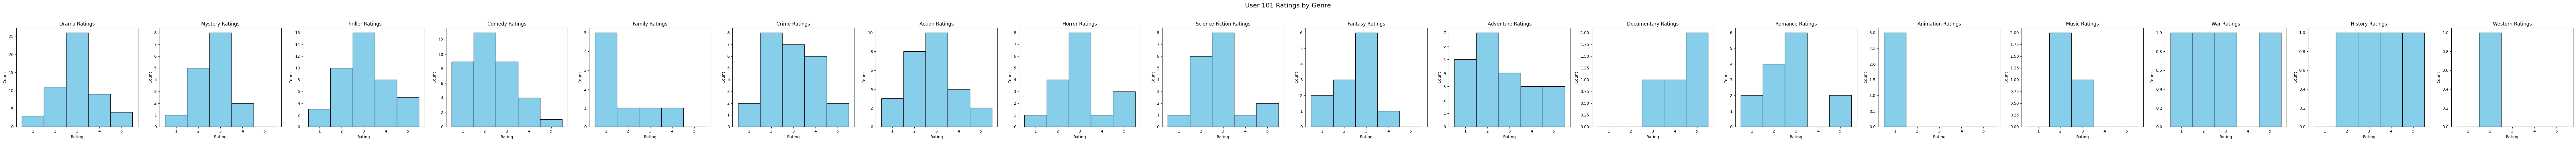
1. **Finding's Importance**: Using movie and user means as an initial imputation before SVD is a good approach but could be limited by scenarios such as the one found above where the user has signficantly different tastes depending on genre. This is because means can coerce values to 3s and 4s rather than capturing strong opinions about more specific types (in this case, genres) of movies.
1. **Experiment Setup**: A 5-fold masking validation strategy was implemented. In each fold, 20% of the known ratings were randomly masked and treated as missing values. One model was processed as described in the steps above. Another model had data preprocessing where the initial dfX_blended data was adjusted by computing a genre bias for which the user watched at least n movies before in that genre (n=3 was found to be optimal through cross-validation). This was done by computing the difference between the dfX_blended user average and the genre average. This signed difference was then added to the dfX_blended average to shift the user's ratings for that particular genre.
1. **Results**: However, on the public leaderboard the genre-conditioned initial imputation resulted in an accuracy of 0.4115, which was not better than the approach described above which showed an accuracy of 0.421. The distribution of the ratings remained similar between the 2 approaches perhaps suggesting that this conditioning was not strong enough to have a substantial effect and was not effective in promoting more decisive ratings (near 1 or 5).

1. **Title**: Direct Filling of Movies with Consistently Low and High Ratings
1. **Idea Discovery**: The Starter Ideas section mentioned that some movies may not need to be processed as the majority of people rate them very high or low and therefore do not distinguish user preferences.
1. **Finding's Importance**: Movies that are almost universally liked or disliked don't help differentiate between users' tastes. Since SVD works by uncovering latent factors that explain the variability in ratings, including movies with little variance can dilute or obscure the more informative patterns. By directly filling these movies with their consensus ratings, instead of processing them through SVD, the amount of noise in the data is reduced.
1. **Experiment Setup**: A 5-fold masking validation strategy was implemented. In each fold, 20% of the known ratings were randomly masked and treated as missing values. Different preprocessing methods were compared against a baseline model (described above) that used no consensus filling. Consensus was determined in one of 2 ways. One emthod was setting a high/low threshold based on average user ratings in the training set (a decimal within 1 to 5) and another was setting the high/low threshold based on voteAvg (a decimal within 0 to 10) as found in the movies.csv file. Multiple low thresholds were tested using a grid search between 1 and 2 with step 0.1 for the user ratings and between 4 and 5 with step 0.1 for the voteAvg. The same process was used to find a high threshold between 4 and 5 for the average user ratings and 7 and 8 for the voteAvg. If a movie fell below the low threshold, all of the ratings were filled with a 1 before SVD. If the movie fell above the high threshold, all of the ratings were filled with a 5 before SVD.
1. **Results**: The thresholds which performed best were 1.3 and 4.5 for the average user ratings and 4.7 and 7.5 for the voteAvg. Using the user rating average outperformed the voteAvg approach on the local cross-validation, so it was submitted to the public leaderboard. However, this approach performed worse than the public leaderboard baseline (0.421) achieving an accuracy of only 0.4149. This suggests that perhaps direct filling did not capture some of the nuances between users for these movies; therefore, the baseline approach was submitted as our final attempt.

<font color=green><h4><b>Task 2. Modeling Ideas</b></h4>
<details>
  <summary>Instructions</summary>
  <div>Explain a <b>key idea</b> that helped with <b>model selection</b> in the format specified above. This may include tuning model parameters (perhaps a grid search with specific parameter range) or some other experiments, search/choice of the suitable model, experiments with postprocessing of model predictions, etc. Use the format in TODO specified above. Remember to provide citation references for the peers to read more into your work.
</div> </details>
</font>

1. **Title**: Model Selection
1. **Idea Discovery**:A variety of decomposition techniques were considered to determine the most suitable factorization method for predicting missing ratings. The goal was to identify the most effective way to extract meaningful latent factors from the user-movie matrix beyond the truncated SVD suggested in the Starter Colab. The major challenge was to identify a model that dealt with the sparsity of the dataset well.

1. **Finding's Importance**:Selecting the optimal model directly impacts predictive accuracy and generalization. Different methods handle missing values and factor representations differently, affecting performance. Truncated SVD (svds) was chosen as the baseline due to its efficiency in handling sparse matrices through low-rank approximation [1]. Regular SVD, which performs full-rank decomposition, was evaluated to determine if preserving the complete latent structure would improve predictions. Non-Negative Matrix Factorization (NMF) was considered for its efficiency with sparse matrices [3]. Sparse PCA was tested to enforce sparsity in principal components, reducing noise and redundancy while improving interpretability.
1. **Experiment Setup**:A 5-fold masking validation strategy was implemented. In each fold, 20% of the known ratings were randomly masked and treated as missing values Each model was implemented in this manner and the mean accuracy across folds was compared with the baseline model, svds. For each model, a grid search was performed to identify the best combination of hyperparameters for the model.
1. **Results**:Truncated SVD (svds) with iterative refinement outperformed all alternative models, by achieving the highest validation accuracy and maintaining stability across the different folds. Regular SVD and NMF showed inconsistent results, with NMF struggling to converge reliably on large datasets. Sparse PCA significantly degraded performance due to its tendency to discard too many important interactions. The hybrid SVD-KNN model reduced accuracy substantially, showing that blending neighborhood-based methods with matrix factorization was not suited for this dataset. With svds, the hyperparameter tuning showed that k = 5 and 50 iterations were the optimal hyperparameter values. Increasing iterations above 50 resulted in overfitting to the training and validation set, and performed poorly on the test set.

<font color=green><h3><b>$\delta$. References</b></h3>
<details>
  <summary>Instructions</summary>
  <div>

1. Cite your sources to help your peers learn from these (and to avoid plagiarism).
1. HOML textbook should be cited, since we used it in this week's learning.
1. Use Google Scholar to draw [APA](https://en.wikipedia.org/wiki/American_Psychological_Association) citation format for books and publications.
1. Cite [StackOverflow](https://stackoverflow.com/), YouTube videos, package docs, open-access textbooks/publicaitons and other meaningful internet resources that you used.
1. We may reward exceptional and meaningful citations (not just a list of [SKL](https://scikit-learn.org/stable/)/[TF](https://www.tensorflow.org/) manual pages and a list of articles.) For example, if you used an idea from a publication, indicate it in TGP with a number that corresponds to its reference in References.

</div> </details>
</font>

1. Pramoditha, R. (2023a, June 27). Truncated svd for dimensionality reduction in sparse feature matrices. Medium. https://rukshanpramoditha.medium.com/truncated-svd-for-dimensionality-reduction-in-sparse-feature-matrices-c083b4af7ddc
1. Khadka, N. (2023, October 11). Ultimate Guide for using truncated SVD for dimensionality reduction. Dataaspirant. https://dataaspirant.com/truncated-svd/
1. Eggert, J., & Korner, E. (n.d.). Sparse coding and NMF. 2004 IEEE International Joint Conference on Neural Networks (IEEE Cat. No.04CH37541), 4, 2529–2533. https://doi.org/10.1109/ijcnn.2004.1381036

<font size=5>⌛</font> <strong><font color=green size=5>Do not exceed competition's runtime limit! Do not write code outside TGP</font></strong>
<hr color=green size=40>

In [ ]:
tmr.ShowTime()    # measure Colab's runtime. Do not remove. Keep as the last cell in your notebook.

Runtime is 33 sec


<details>
  <summary><font size=5><b>💡Starter Ideas</b></font></summary>
  <div>

1. Tune model **hyperparameters**.
  1. SVD's $k$ might be user-perceived movie genres (perhaps, an average user categorizes movies into just 5 or 50 genres) [🎦](https://youtu.be/sooj-_bXWgk)
1. Try smarter **sampling** from the training set to avoid using all observations (due to time constraint)
  1. Some movies may have consistent high/low ratings and do not distinguish user preferences (just add to runtime)
1. Try SVD on groups (say movie genres) with the largest impact on overall accuracy
1. Try smarter initial imputation, perhaps, conditioned on movie genres or other observed features
1. Try clustering techniques from [SKL](https://scikit-learn.org/stable/modules/clustering.html)
1. Try engineering new features using Movies' data (`movies.csv`)
  1. For example, you can hot-encode movie genre and concatenate it to each verticle movie vector of ratings. This injects movie attributes into your rating matrix. If you had user info, you could similarly concatenate user attribute vectors with their rating vectors.
1. Try supervised approach on clusters or engineered features
1. Try shift/scale ratings. Recall: SVD seeks largest quadratic error from mean without shifting first, like variance does. Since $1^2\ll5^2$, SVD might work better for higher ratings.
  1. Note: the baseline model squeezes predictions towards ratings 3 and 4, which is not the original distribution.
1. Try feature restriction, selection, and regularization (see ESL pp.140-141)
1. Do a thorough EDA. Are there movies that are liked by most viewers?
1. Try Robust PCA (RPC) [🎦](https://www.youtube.com/watch?v=yDpz0PqULXQ), [RPCA Github](https://github.com/dganguli/robust-pca)
1. Find polarized movies and tune for them (like "*Napoleon Dynamite*"). See [&#127910;](https://youtu.be/ImpV70uLxyw)
1. Try KNN [📄](https://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.143.596&rep=rep1&type=pdf), [📄](https://scholar.google.com/scholar?q=knn+netflix+prize)
1. Learn more methods to build/use latent representations [🎦](https://youtu.be/n3RKsY2H-NE),  [📄](https://ieeexplore.ieee.org/abstract/document/5197422), [📄](https://scholar.google.com/scholar?q=netflix+prize+challenge), [&#127910;](https://www.youtube.com/results?search_query=netflix+prize+svd), [📄](https://www.aaai.org/Papers/AAAI/2002/AAAI02-029.pdf),
1. Not for this competition, but... In another setting, you could use graph neural networks (GNN) or shief neural networks (a generalized GNN) to build user and movie embeddings (in the same vector space). Then recommendations (or ratings) could be based on the distance between user vectors and movie vectors. Interestingly, GNN can incorporate user and movie attributes into the embedding more naturally. [📄](https://scholar.google.com/scholar?hl=en&as_sdt=0%2C5&q=graph+neural+networks&btnG=), [📄](https://arxiv.org/pdf/2012.06333), [📄](https://arxiv.org/pdf/2206.08702)

</div> </details>